# Conditional Model A — Regression Analysis

Walk-forward grid using **regression** models to predict `target_y_long_net` (continuous PnL) directly.

Key differences vs classification:
- **Signal**: `y_hat` (predicted PnL magnitude) instead of `p_hat` (probability)
- **Position rule**: sign(y_hat) > 0 → long, < 0 → short
- **Selection**: by |y_hat| magnitude (conviction = predicted return size)
- **IC**: Spearman(y_hat, target_y_long_net) — directly tests ranking of *magnitudes*, not just direction
- **Metrics**: ICIR, IC, MAE, R², directional accuracy (no AUC/Brier)

Protocol: two-pass walk-forward, rolling 252d, refit every 21d, 1d purge, 2023-04-19 → 2025-06-30.

In [1]:
import sys, warnings
sys.path.insert(0, '../code')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm

from scipy.stats import spearmanr

from ml_protocol.evaluator import (
    comparison_table, ml_metrics, ic_series_intraday, icir, ic_tstat
)

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print('Imports OK')

Imports OK


In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
import os
ROOT    = os.path.abspath('..')
OUTDIR  = os.path.join(ROOT, 'output', 'conditional_model_A', 'reg_grid_v3')
FIGDIR  = os.path.join(ROOT, 'output', 'figures')
os.makedirs(FIGDIR, exist_ok=True)

PRED_FILE  = os.path.join(OUTDIR, 'reg_predictions.parquet')
LOG_FILE   = os.path.join(OUTDIR, 'reg_split_log.parquet')

# ── Dates ─────────────────────────────────────────────────────────────────────
S1_START = pd.Timestamp('2023-04-19')
S1_MID   = pd.Timestamp('2024-05-01')
S2_START = pd.Timestamp('2025-07-01')

# Best model — ridge: ICIR=2.03, ic_oos=0.046, 0 dead days, ic_gap=0.031
# (lasso ICIR=2.68 is biased — 126 days where all predictions are constant)
BEST_MODEL = 'ridge'

# Representative moneyness: 1 obs per (date, bar, family) for portfolio analysis
REP_MNES = {
    'straddle':           '1/1',
    'strangle':           '0.99/1.01',
    'iron_butterfly':     '0.99/1/1.01',
    'iron_condor':        '0.99/0.995/1.005/1.01',
    'risk_reversal':      '0.99/1.01',
    'bull_call_spread':   '0.99/1.01',
    'bear_put_spread':    '0.985/1',
    'call_ratio_spread':  '0.99/1.01',
    'put_ratio_spread':   '0.985/1',
    'call_butterfly':     '0.99/1/1.01',
    'put_butterfly':      '0.99/0.995/1',
}

FAMILY_MAP = {
    'straddle':          'Straddle',
    'strangle':          'Strangle',
    'iron_butterfly':    'Iron Fly',
    'iron_condor':       'Iron Condor',
    'risk_reversal':     'Risk Rev',
    'bull_call_spread':  'Bull Call',
    'bear_put_spread':   'Bear Put',
    'call_ratio_spread': 'Call Ratio',
    'put_ratio_spread':  'Put Ratio',
    'call_butterfly':    'Call Fly',
    'put_butterfly':     'Put Fly',
}
print('Config OK')

In [7]:
# ── Load predictions ──────────────────────────────────────────────────────────
preds    = pd.read_parquet(PRED_FILE)
split_log = pd.read_parquet(LOG_FILE)

preds['family'] = preds['option_type'].map(FAMILY_MAP)

print(f'Predictions : {len(preds):,} rows')
print(f'Dates       : {preds.quote_date.min().date()} → {preds.quote_date.max().date()}')
print(f'            : {preds.quote_date.nunique()} unique trading days')
print(f'Models      : {sorted(preds.model_id.unique())}')
print(f'Families    : {sorted(preds.option_type.unique())}')
print(f'Bars        : {preds.quote_time.nunique()} intraday time slots')
print()
print('y_hat stats (hgb_reg):')
print(preds[preds.model_id == BEST_MODEL]['y_hat'].describe().round(6))

Predictions : 16,564,776 rows
Dates       : 2023-04-19 → 2025-06-30
            : 546 unique trading days
Models      : ['hgb_reg', 'hgb_super', 'hgb_tight', 'hgb_ultra', 'lasso', 'lasso_no_int', 'lgbm_super', 'lgbm_ultra', 'ridge', 'ridge_no_int', 'xgb_super', 'xgb_ultra']
Families    : ['bear_put_spread', 'bull_call_spread', 'call_butterfly', 'call_ratio_spread', 'iron_butterfly', 'iron_condor', 'put_butterfly', 'put_ratio_spread', 'risk_reversal', 'straddle', 'strangle']
Bars        : 72 intraday time slots

y_hat stats (hgb_reg):
count   1380398.0000
mean         -0.0001
std           0.0000
min          -0.0002
25%          -0.0001
50%          -0.0001
75%          -0.0001
max           0.0002
Name: y_hat, dtype: float64


## Comparison Table — Sélection du meilleur modèle

**Signal** = `y_hat` (predicted PnL). **IC** = Spearman(y_hat, target_y_long_net) per (date, time) slot.

Critères de sélection :
1. `icir` maximal (ICIR unbiaisé : les jours morts comptent comme IC=0, pas exclus)
2. `ic_dead_days` = 0 : jours où **toutes** les prédictions sont constantes → IC indéfini
3. `ic_tstat` > 1.96 (significatif au seuil 5%, NW-HAC)
4. `ic_gap` faible (pas de surapprentissage)
5. `dir_acc` > 0.50

> **Note** : Lasso a un ICIR élevé mais ~126 jours morts (L1 annule tous les coefficients → prédiction constante → variance cross-sectionnelle nulle). ElasticNet (v4) remplace Lasso pour corriger ce problème.

In [ ]:
# Comparison table — takes a few minutes (IC per date/time for each model)
ct = comparison_table(
    preds, split_log,
    task       = 'regression',
    signal_col = 'y_hat',
    return_col = 'target_y_long_net',
    time_col   = 'quote_time',
)
ct.to_csv(os.path.join(OUTDIR, 'reg_comparison_table_final.csv'), index=False)
print('Comparison table saved')
ct

In [ ]:
# Focused view: columns relevant to regression model selection
# ic_dead_days = days where ALL time slots had constant y_hat → IC undefined
# ICIR is unbiased: dead days count as IC=0 (not excluded from mean/std)
ct[['model_id', 'icir', 'ic_oos', 'ic_tstat', 'ic_dead_days',
    'ic_gap', 'dir_acc', 'mae', 'r2', 'sig_bhy']].round(4)

In [14]:
# ── Best model predictions ────────────────────────────────────────────────────
best = preds[preds['model_id'] == BEST_MODEL].copy()
print(f'Best model  : {BEST_MODEL}')
print(f'Rows        : {len(best):,}')
print(f'y_hat > 0   : {(best.y_hat > 0).mean():.1%}  (long signals)')
print(f'y_hat < 0   : {(best.y_hat < 0).mean():.1%}  (short signals)')

Best model  : hgb_super
Rows        : 1,380,398
y_hat > 0   : 3.5%  (long signals)
y_hat < 0   : 96.5%  (short signals)


## IC Dynamics — Stabilité temporelle du signal

ICIR   : 2.34
IC mean: 0.0558
IC std : 0.3778
IC t   : 2.47
% days IC > 0 : 31.1%


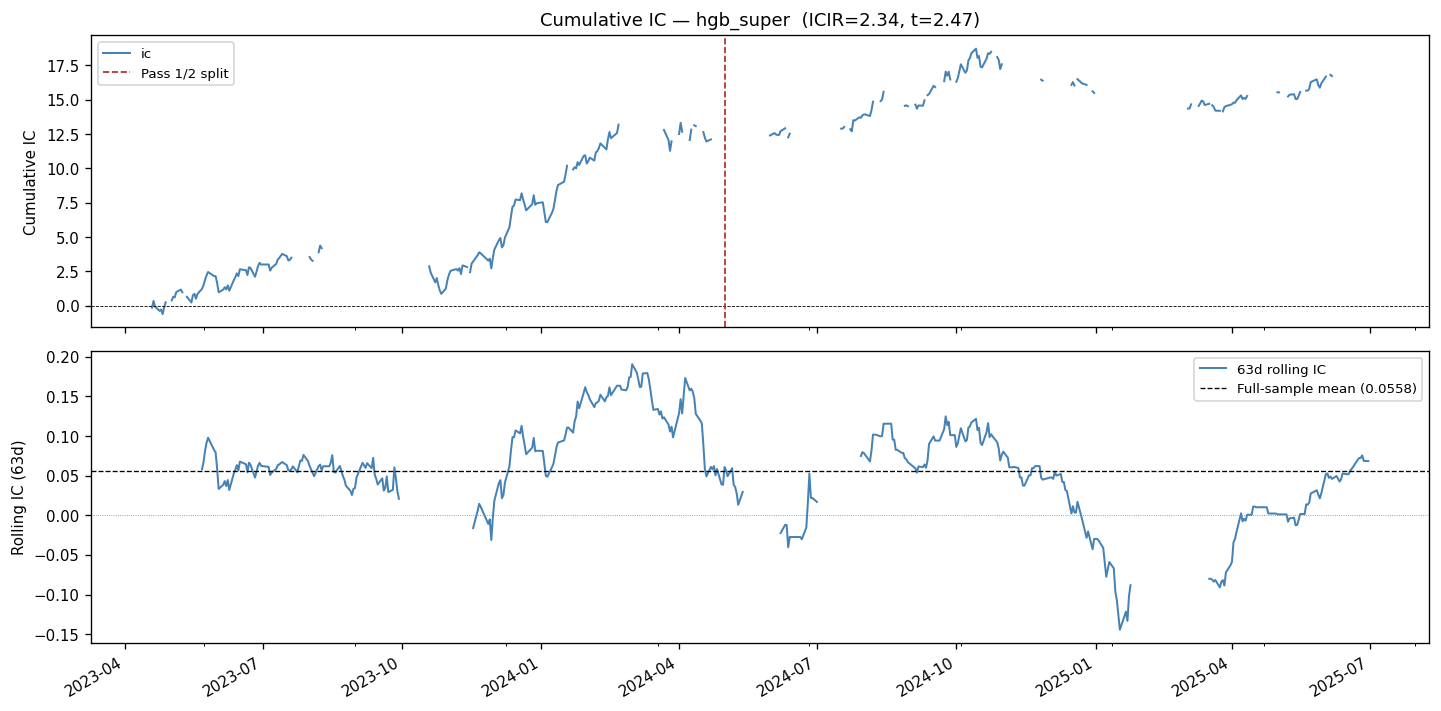

In [15]:
# Daily IC series (intraday average)
ic = ic_series_intraday(
    best,
    signal_col = 'y_hat',
    return_col = 'target_y_long_net',
    time_col   = 'quote_time',
)

print(f'ICIR   : {icir(ic):.2f}')
print(f'IC mean: {ic.mean():.4f}')
print(f'IC std : {ic.std():.4f}')
print(f'IC t   : {ic_tstat(ic):.2f}')
print(f'% days IC > 0 : {(ic > 0).mean():.1%}')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Cumulative IC
ax = axes[0]
ic.cumsum().plot(ax=ax, color='steelblue', lw=1.2)
ax.axhline(0, color='k', lw=0.5, ls='--')
if S1_MID in ic.index:
    ax.axvline(S1_MID, color='firebrick', lw=1, ls='--', label='Pass 1/2 split')
ax.set_ylabel('Cumulative IC')
ax.set_title(f'Cumulative IC — {BEST_MODEL}  (ICIR={icir(ic):.2f}, t={ic_tstat(ic):.2f})')
ax.legend(fontsize=8)

# Rolling 63d IC
ax = axes[1]
ic.rolling(63, min_periods=21).mean().plot(ax=ax, color='steelblue', lw=1.2, label='63d rolling IC')
ax.axhline(ic.mean(), color='k', lw=0.8, ls='--', label=f'Full-sample mean ({ic.mean():.4f})')
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_ylabel('Rolling IC (63d)')
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_ic_dynamics.pdf'), bbox_inches='tight')
plt.show()

## IC par famille de stratégie

     family    icir  ic_mean  ic_tstat  dir_acc  n_days
   Strangle 16.3568   0.5796    5.4059   0.9133      20
    Put Fly  6.1736   0.2884    2.5113   0.6835      60
   Iron Fly  3.9293   0.1729    1.0956   0.4536      27
   Bear Put  3.4626   0.0805    1.3456   0.6193      54
  Put Ratio  3.2836   0.0760    1.4612   0.6132      67
   Call Fly  3.0639   0.1058    1.8239   0.5440      80
  Bull Call  0.2258   0.0075    0.1158   0.5674      54
   Risk Rev -0.7739  -0.0340   -0.2620   0.2902      52
 Call Ratio -1.2761  -0.0380   -0.8416   0.5593      83
Iron Condor -3.7642  -0.1286   -0.9036   0.2582      20
   Straddle     NaN      NaN       NaN   0.6248       0


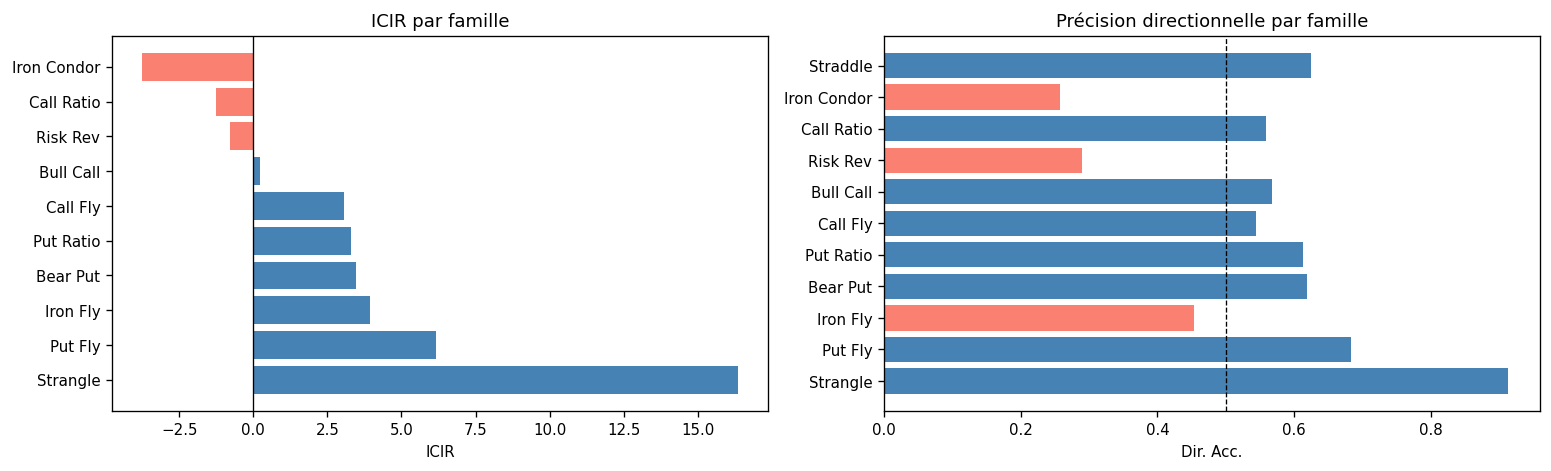

In [17]:
fam_rows = []
for fam, grp in best.groupby('option_type'):
    ic_f = ic_series_intraday(grp, signal_col='y_hat', return_col='target_y_long_net', time_col='quote_time')
    valid = np.isfinite(grp['y_hat']) & np.isfinite(grp['target_y_long_net'])
    fam_rows.append({
        'family':   FAMILY_MAP.get(fam, fam),
        'icir':     icir(ic_f),
        'ic_mean':  ic_f.mean(),
        'ic_tstat': ic_tstat(ic_f),
        'dir_acc':  float(np.mean(np.sign(grp.loc[valid, 'y_hat']) == np.sign(grp.loc[valid, 'target_y_long_net']))),
        'n_days':   ic_f.dropna().__len__(),
    })

fam_df = pd.DataFrame(fam_rows).sort_values('icir', ascending=False)
print(fam_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
colors = ['steelblue' if v > 0 else 'salmon' for v in fam_df['icir']]
ax.barh(fam_df['family'], fam_df['icir'], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('ICIR'); ax.set_title('ICIR par famille')

ax = axes[1]
colors2 = ['steelblue' if v > 0.5 else 'salmon' for v in fam_df['dir_acc']]
ax.barh(fam_df['family'], fam_df['dir_acc'], color=colors2)
ax.axvline(0.5, color='k', lw=0.8, ls='--')
ax.set_xlabel('Dir. Acc.'); ax.set_title('Précision directionnelle par famille')

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_ic_by_family.pdf'), bbox_inches='tight')
plt.show()

## IC par heure de la journée

In [ ]:
time_rows = []
for t, grp in best.groupby('quote_time'):
    ic_t = ic_series_intraday(
        grp.assign(quote_time_=t),  # single time → daily IC
        signal_col='y_hat', return_col='target_y_long_net', time_col='quote_time',
    )
    time_rows.append({
        'time': t,
        'icir': icir(ic_t),
        'ic':   ic_t.mean(),
        'tstat': ic_tstat(ic_t),
    })

time_df = pd.DataFrame(time_rows).sort_values('time').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(time_df['time'], time_df['ic'], marker='.', ms=4, color='steelblue', lw=1)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Heure'); ax.set_ylabel('IC moyen')
ax.set_title('IC par heure')
ax.tick_params(axis='x', labelrotation=90, labelsize=6)

ax = axes[1]
ax.plot(time_df['time'], time_df['icir'], marker='.', ms=4, color='darkorange', lw=1)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Heure'); ax.set_ylabel('ICIR')
ax.set_title('ICIR par heure')
ax.tick_params(axis='x', labelrotation=90, labelsize=6)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_ic_by_time.pdf'), bbox_inches='tight')
plt.show()
print('Top 5 heures par ICIR:')
print(time_df.nlargest(5, 'icir')[['time','icir','ic','tstat']].to_string(index=False))

## IC Heatmap — heure × famille

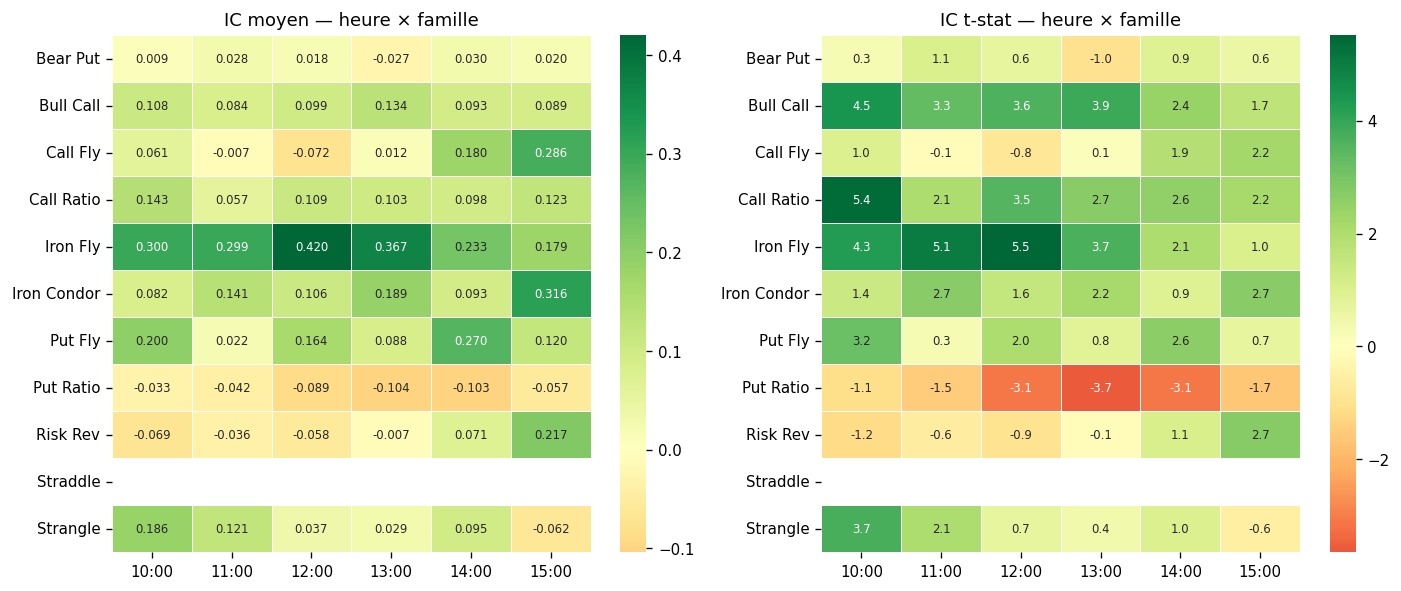

In [ ]:
# Select a subset of representative hours to keep heatmap readable
HOUR_LABELS = [f'{h:02d}:00' for h in range(10, 16)]
best_sub = best[best['quote_time'].isin(HOUR_LABELS)].copy()

mat_ic   = pd.DataFrame(index=sorted(best_sub['option_type'].unique()),
                        columns=HOUR_LABELS, dtype=float)
mat_t    = mat_ic.copy()

for ot, grp_ot in best_sub.groupby('option_type'):
    for t, grp_t in grp_ot.groupby('quote_time'):
        x = grp_t['y_hat'].values; y_ = grp_t['target_y_long_net'].values
        mask = np.isfinite(x) & np.isfinite(y_)
        if mask.sum() < 10:
            continue
        # daily IC
        ic_t = ic_series_intraday(grp_t, signal_col='y_hat', return_col='target_y_long_net', time_col='quote_time')
        mat_ic.loc[ot, t]  = ic_t.mean()
        mat_t.loc[ot, t]   = ic_tstat(ic_t)

mat_ic.index = [FAMILY_MAP.get(i, i) for i in mat_ic.index]
mat_t.index  = mat_ic.index

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(mat_ic.astype(float), ax=axes[0], center=0, cmap='RdYlGn',
            annot=True, fmt='.3f', annot_kws={'size': 7}, linewidths=.3)
axes[0].set_title('IC moyen — heure × famille')

sns.heatmap(mat_t.astype(float), ax=axes[1], center=0, cmap='RdYlGn',
            annot=True, fmt='.1f', annot_kws={'size': 7}, linewidths=.3)
axes[1].set_title('IC t-stat — heure × famille')

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_ic_heatmap_time_family.pdf'), bbox_inches='tight')
plt.show()

## Régimes macro & volatilité

In [ ]:
# Load macro dummies from the original parquet
PARQUET = os.path.join(ROOT, 'data', 'processed', 'conditional_features_5min.parquet')
raw = pd.read_parquet(PARQUET, columns=['quote_date', 'quote_time', 'is_cpi_day', 'is_nfp_day',
                                         'is_fomc_day', 'is_high_vix_lag1', 'atm_iv'])
daily_macro = raw.groupby('quote_date').agg(
    is_cpi  = ('is_cpi_day',      'max'),
    is_nfp  = ('is_nfp_day',      'max'),
    is_fomc = ('is_fomc_day',     'max'),
    hi_vix  = ('is_high_vix_lag1','max'),
    atm_iv  = ('atm_iv',          'mean'),
).reset_index()

ic_daily = ic.reset_index()
ic_daily.columns = ['quote_date', 'ic']
ic_daily = ic_daily.merge(daily_macro, on='quote_date', how='left')

events = {'CPI': 'is_cpi', 'NFP': 'is_nfp', 'FOMC': 'is_fomc', 'Hi VIX': 'hi_vix'}

print(f"{'Event':<12} {'IC (event)':>12} {'IC (normal)':>12} {'N event':>9} {'t-stat':>8}")
print('-' * 57)
for label, col in events.items():
    ev  = ic_daily.loc[ic_daily[col] == 1, 'ic'].dropna()
    non = ic_daily.loc[ic_daily[col] == 0, 'ic'].dropna()
    diff = ev.mean() - non.mean()
    from scipy.stats import ttest_ind
    t, _ = ttest_ind(ev, non, equal_var=False) if len(ev) > 1 else (np.nan, np.nan)
    print(f'{label:<12} {ev.mean():>12.4f} {non.mean():>12.4f} {len(ev):>9d} {t:>8.2f}')

# VIX quartile regime
ic_daily['vix_q'] = pd.qcut(ic_daily['atm_iv'], 4, labels=['Q1 low','Q2','Q3','Q4 hi'])
print('\nIC par quartile ATM IV:')
print(ic_daily.groupby('vix_q', observed=True)['ic'].agg(['mean','std','count']).round(4))

Event          IC (event)  IC (normal)   N event   t-stat
---------------------------------------------------------
CPI                0.0918       0.0432        26     0.61
NFP                0.0314       0.0462        26    -0.23
FOMC               0.1278       0.0427        18     1.23
Hi VIX             0.1693       0.0403        22     1.96

IC par quartile ATM IV:
          mean    std  count
vix_q                       
Q1 low -0.0397 0.3619    137
Q2      0.0820 0.3411    136
Q3      0.0685 0.3728    136
Q4 hi   0.0717 0.3373    137


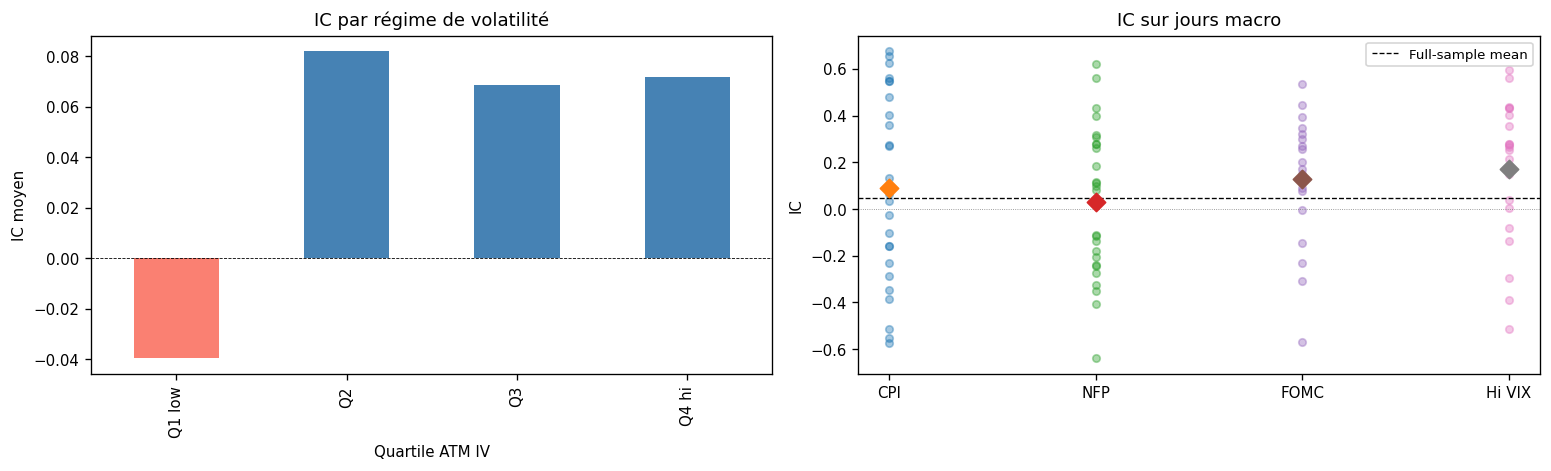

In [ ]:
# Visualise VIX regime
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
vix_ic = ic_daily.groupby('vix_q', observed=True)['ic'].mean()
vix_ic.plot(kind='bar', ax=ax, color=['steelblue' if v > 0 else 'salmon' for v in vix_ic])
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Quartile ATM IV'); ax.set_ylabel('IC moyen')
ax.set_title('IC par régime de volatilité')

ax = axes[1]
for label, col in events.items():
    ev_ic = ic_daily.loc[ic_daily[col] == 1, 'ic'].dropna()
    ax.scatter([label] * len(ev_ic), ev_ic, alpha=0.4, s=20)
    ax.scatter([label], [ev_ic.mean()], marker='D', s=60, zorder=5)
ax.axhline(ic_daily['ic'].mean(), color='k', lw=0.8, ls='--', label='Full-sample mean')
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_ylabel('IC'); ax.set_title('IC sur jours macro')
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_ic_regimes.pdf'), bbox_inches='tight')
plt.show()

## Diagnostics ML — Déciles de conviction

On rank les prédictions par `|y_hat|` (conviction = magnitude de la prédiction). Si le modèle est utile, les déciles extrêmes (haute conviction) devraient avoir une meilleure précision directionnelle et/ou un PnL plus élevé.

 decile  dir_acc  mean_pnl  mean_yhat_abs      n
      1   0.5033   -0.0001         0.0000 138040
      2   0.5042   -0.0001         0.0001 138040
      3   0.5084   -0.0001         0.0001 138040
      4   0.5138   -0.0001         0.0001 138039
      5   0.5239   -0.0001         0.0002 138040
      6   0.5336   -0.0000         0.0003 138040
      7   0.5431   -0.0000         0.0003 138039
      8   0.5533   -0.0000         0.0004 138040
      9   0.5592   -0.0001         0.0006 138040
     10   0.5768   -0.0002         0.0010 138040


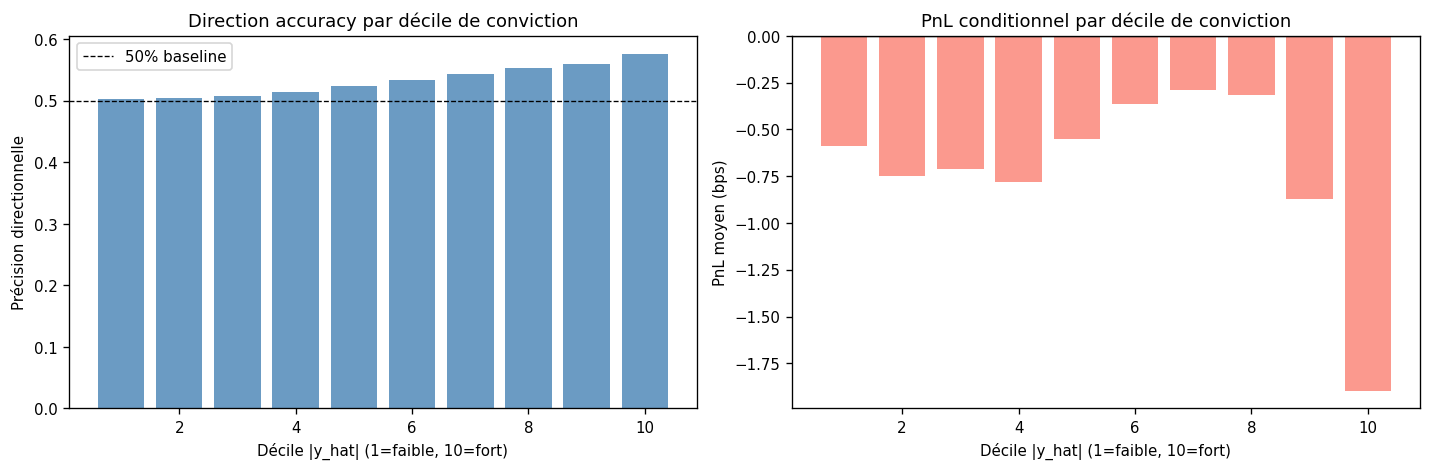

In [ ]:
b = best.copy()
b['abs_yhat'] = b['y_hat'].abs()
b['decile']   = pd.qcut(b['abs_yhat'], 10, labels=False) + 1  # 1=lowest conviction, 10=highest

b['dir_correct'] = (np.sign(b['y_hat']) == np.sign(b['target_y_long_net'])).astype(float)
b['pnl_taken']   = np.where(b['sign'] == 1, b['target_y_long_net'], b['target_y_short_net'])

dec = b.groupby('decile', observed=True).agg(
    dir_acc  = ('dir_correct', 'mean'),
    mean_pnl = ('pnl_taken',   'mean'),
    mean_yhat_abs = ('abs_yhat', 'mean'),
    n        = ('y_hat',       'count'),
).reset_index()
print(dec.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(dec['decile'], dec['dir_acc'], color='steelblue', alpha=0.8)
ax.axhline(0.5, color='k', lw=0.8, ls='--', label='50% baseline')
ax.set_xlabel('Décile |y_hat| (1=faible, 10=fort)')
ax.set_ylabel('Précision directionnelle')
ax.set_title('Direction accuracy par décile de conviction')
ax.legend()

ax = axes[1]
colors = ['steelblue' if v > 0 else 'salmon' for v in dec['mean_pnl']]
ax.bar(dec['decile'], dec['mean_pnl'] * 10000, color=colors, alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Décile |y_hat| (1=faible, 10=fort)')
ax.set_ylabel('PnL moyen (bps)')
ax.set_title('PnL conditionnel par décile de conviction')

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_decile_analysis.pdf'), bbox_inches='tight')
plt.show()

## Analyse économique — Portefeuille conditionnel

**Règle de position** : `sign(y_hat) = +1` → long (`target_y_long_net`), `= -1` → short (`target_y_short_net`).

On utilise les moneyness représentatifs (`REP_MNES`) — 1 observation par (date, bar, famille) — pour éviter de sur-représenter certaines familles.

In [ ]:
def nw_tstat(s, nlags=None):
    s = pd.Series(s).dropna(); n = len(s)
    if n < 10:
        return np.nan
    lgs = nlags if nlags else int(np.floor(4 * (n / 100) ** (2/9)))
    ols = sm.OLS(s.values, np.ones(n)).fit(cov_type='HAC', cov_kwds={'maxlags': lgs})
    return float(ols.tvalues[0])

def sharpe(r):
    r = pd.Series(r).dropna()
    return r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan

# Filter to representative moneyness
best['rep'] = best.apply(lambda r: REP_MNES.get(r['option_type']) == r['mnes'], axis=1)
rep = best[best['rep']].copy()
rep['pnl_cond'] = np.where(rep['sign'] == 1, rep['target_y_long_net'], rep['target_y_short_net'])
rep['pnl_long'] = rep['target_y_long_net']  # unconditional long

print(f'Rep. moneyness rows : {len(rep):,}')
print(f'Families            : {rep.option_type.nunique()}')

Rep. moneyness rows : 323,509
Families            : 11


In [ ]:
# ── Summary table: unconditional vs conditional at 13:30 ──────────────────────
rep10 = rep[rep['quote_time'] == '13:30'].copy()

rows_econ = []
for ot, grp in rep10.groupby('option_type'):
    for label, col in [('Long inconditionnel', 'pnl_long'), ('Conditionnel sign(y_hat)', 'pnl_cond')]:
        r = grp.groupby('quote_date')[col].sum()  # daily PnL across moneyness
        rows_econ.append({
            'famille': FAMILY_MAP.get(ot, ot),
            'stratégie': label,
            'mean_pnl': r.mean(),
            'SR': sharpe(r),
            't-stat': nw_tstat(r),
            'n_days': len(r),
        })

econ_df = pd.DataFrame(rows_econ)
print(econ_df.round(4).to_string(index=False))

    famille                stratégie  mean_pnl      SR  t-stat  n_days
   Bear Put      Long inconditionnel   -0.0002 -1.0883 -1.4327     475
   Bear Put Conditionnel sign(y_hat)   -0.0001 -0.4214 -0.6389     475
  Bull Call      Long inconditionnel   -0.0001 -0.3915 -0.4531     390
  Bull Call Conditionnel sign(y_hat)   -0.0001 -0.2986 -0.3516     390
   Call Fly      Long inconditionnel    0.0001  0.8738  1.1328     390
   Call Fly Conditionnel sign(y_hat)    0.0001  0.4095  0.4854     390
 Call Ratio      Long inconditionnel   -0.0001 -0.2999 -0.3483     390
 Call Ratio Conditionnel sign(y_hat)   -0.0000 -0.1240 -0.1575     390
   Iron Fly      Long inconditionnel    0.0002  1.3393  1.7312     390
   Iron Fly Conditionnel sign(y_hat)    0.0002  1.0611  1.3970     390
Iron Condor      Long inconditionnel    0.0000  0.2845  0.3558     390
Iron Condor Conditionnel sign(y_hat)   -0.0000 -0.1455 -0.1922     390
    Put Fly      Long inconditionnel   -0.0001 -1.2102 -1.8376     544
    Pu

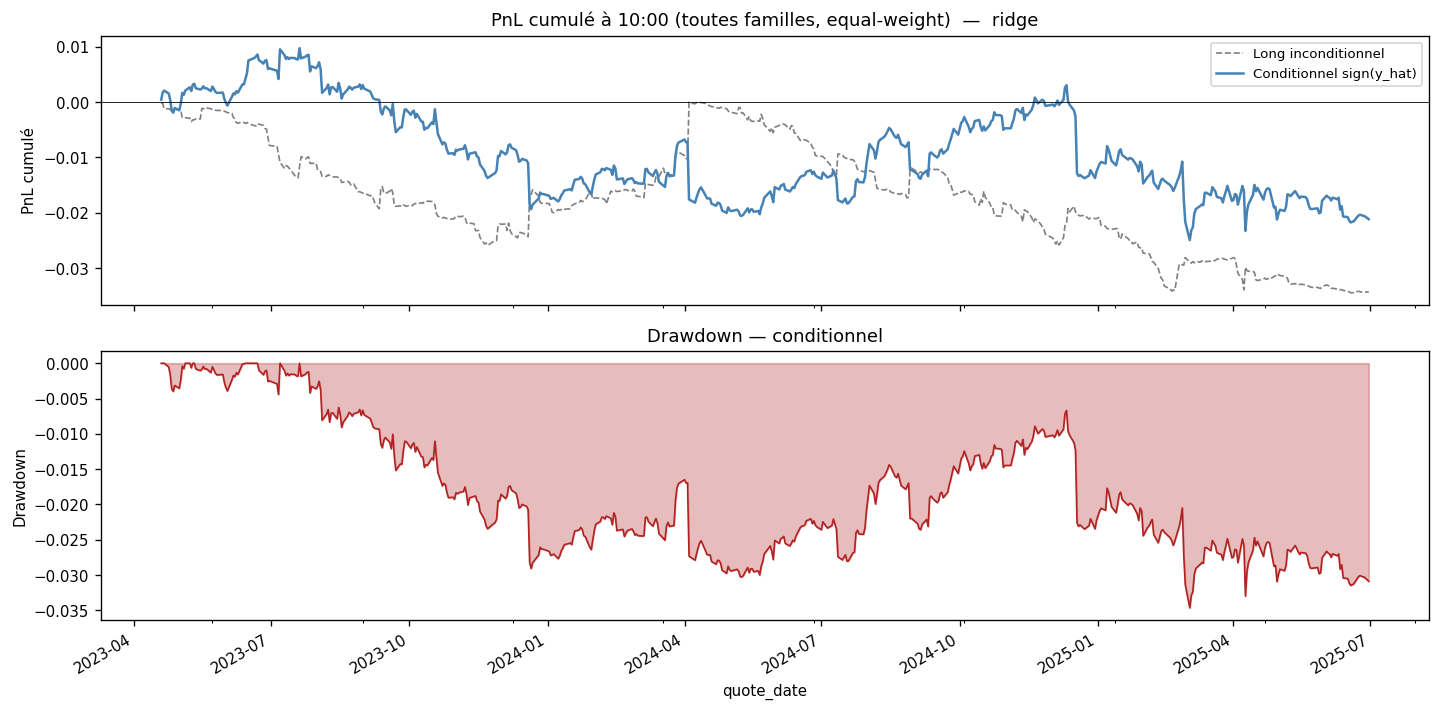

SR cond    : -0.44
SR incond  : -1.06
t-stat cond: -0.68


In [ ]:
# ── Cumulative PnL — conditionnel vs inconditionnel ───────────────────────────
# Aggregate all families, equal weight, at 10:00
agg10 = rep10.groupby('quote_date')[['pnl_long', 'pnl_cond']].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
agg10['pnl_long'].cumsum().plot(ax=ax, label='Long inconditionnel', color='gray', lw=1, ls='--')
agg10['pnl_cond'].cumsum().plot(ax=ax, label='Conditionnel sign(y_hat)', color='steelblue', lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('PnL cumulé')
ax.set_title(f'PnL cumulé à 10:00 (toutes familles, equal-weight)  —  {BEST_MODEL}')
ax.legend(fontsize=8)

ax = axes[1]
# Drawdown conditionnel
cum = agg10['pnl_cond'].cumsum()
dd = cum - cum.cummax()
dd.plot(ax=ax, color='firebrick', lw=1)
ax.fill_between(dd.index, dd, alpha=0.3, color='firebrick')
ax.set_ylabel('Drawdown')
ax.set_title('Drawdown — conditionnel')

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_cumulative_pnl_10h.pdf'), bbox_inches='tight')
plt.show()

print(f'SR cond    : {sharpe(agg10["pnl_cond"]):.2f}')
print(f'SR incond  : {sharpe(agg10["pnl_long"]):.2f}')
print(f't-stat cond: {nw_tstat(agg10["pnl_cond"]):.2f}')

## Heatmap conditionnel — (barre × famille)

PnL conditionnel moyen et t-stat NW-HAC pour chaque (heure, famille).  
Signal = `y_hat`, position = `sign(y_hat)`, moneyness représentatifs uniquement.

In [ ]:
TOPK   = 2   # long top-K, short bottom-K by y_hat per (date, bar)
THRESH = 0.00005 # |y_hat| threshold for high-conviction trades

# ── Top-K selection ───────────────────────────────────────────────────────────
rep['_rank'] = rep.groupby(['quote_date','quote_time'])['y_hat'].rank(method='first')
rep['_n']    = rep.groupby(['quote_date','quote_time'])['y_hat'].transform('count')

rep['cond_topk'] = np.nan
long_mask  = rep['_rank'] > (rep['_n'] - TOPK)
short_mask = rep['_rank'] <= TOPK
rep.loc[long_mask,  'cond_topk'] = rep.loc[long_mask,  'target_y_long_net']
rep.loc[short_mask, 'cond_topk'] = rep.loc[short_mask, 'target_y_short_net']
rep.drop(columns=['_rank','_n'], inplace=True)

# ── Threshold selection ───────────────────────────────────────────────────────
hi_conv = rep['y_hat'].abs() >= THRESH
rep['cond_thr'] = np.nan
rep.loc[hi_conv, 'cond_thr'] = np.where(
    rep.loc[hi_conv, 'sign'] == 1,
    rep.loc[hi_conv, 'target_y_long_net'],
    rep.loc[hi_conv, 'target_y_short_net'],
)

print(f'Top-{TOPK}: {rep["cond_topk"].notna().mean():.1%} observations conservées')
print(f'Thresh {THRESH:.5f}: {rep["cond_thr"].notna().mean():.1%} observations conservées')

Top-2: 42.5% observations conservées
Thresh 0.00005: 86.0% observations conservées


In [ ]:
# Summary: unconditional vs top-K vs threshold
configs = [
    ('Inconditionnel long',        'pnl_long'),
    ('Conditionnel sign(y_hat)',   'pnl_cond'),
    (f'Top-{TOPK}/Bottom-{TOPK}', 'cond_topk'),
    (f'|y_hat|≥{THRESH:.5f}',     'cond_thr'),
]

print(f"{'Stratégie':<30} {'mean PnL':>10} {'SR':>8} {'t-stat':>8} {'N obs':>8}")
print('-' * 68)
for label, col in configs:
    s = rep[col].dropna()
    daily = rep.groupby('quote_date')[col].mean().dropna()
    print(f'{label:<30} {s.mean():>10.5f} {sharpe(daily):>8.2f} {nw_tstat(daily):>8.2f} {len(s):>8,}')

Stratégie                        mean PnL       SR   t-stat    N obs
--------------------------------------------------------------------
Inconditionnel long              -0.00005    -1.54    -2.59  323,509
Conditionnel sign(y_hat)         -0.00006    -0.61    -0.88  323,509
Top-2/Bottom-2                   -0.00003    -0.21    -0.32  137,485
|y_hat|≥0.00005                  -0.00006    -0.54    -0.78  278,117


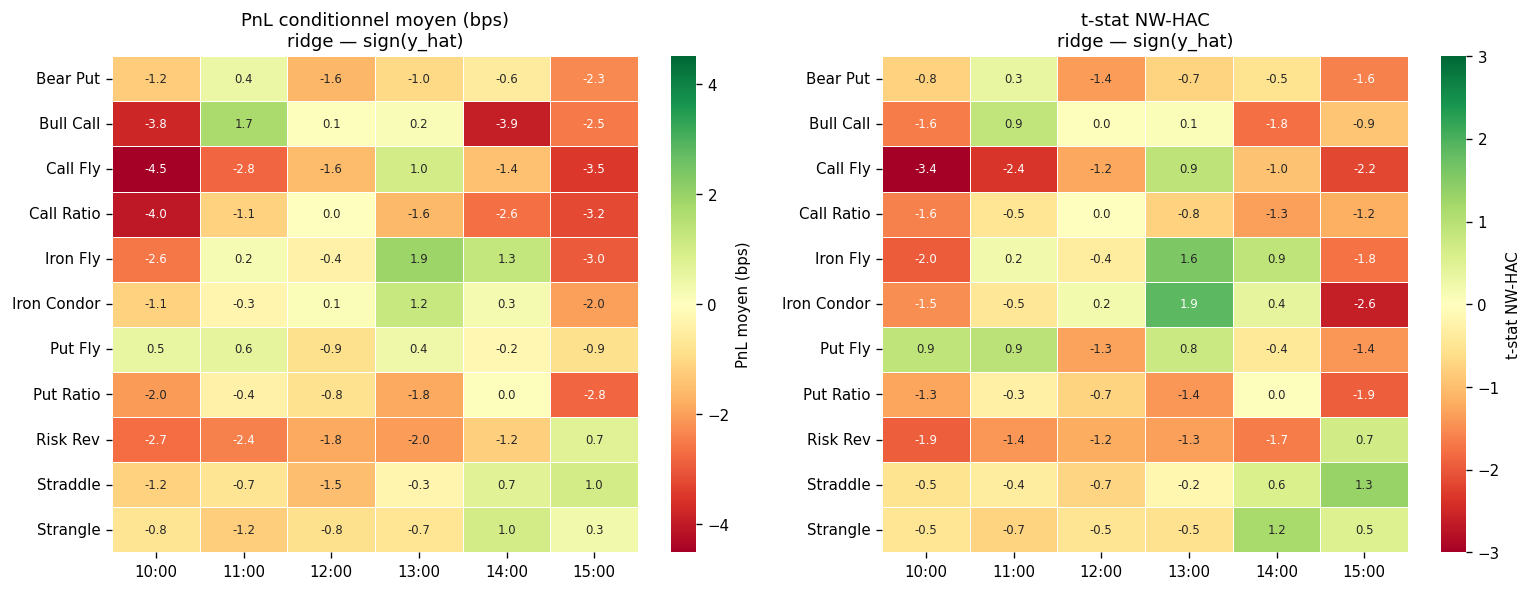

In [ ]:
# ── Heatmaps PnL × t-stat par (barre, famille) ───────────────────────────────
SEL_HOURS = [f'{h:02d}:00' for h in range(10, 16)]
rep_sub = rep[rep['quote_time'].isin(SEL_HOURS)].copy()

families_ord = sorted(rep_sub['option_type'].unique())
mat_pnl  = pd.DataFrame(index=[FAMILY_MAP.get(f, f) for f in families_ord], columns=SEL_HOURS, dtype=float)
mat_tstat = mat_pnl.copy()

for ot, fam in zip(families_ord, mat_pnl.index):
    for t in SEL_HOURS:
        grp = rep_sub[(rep_sub['option_type'] == ot) & (rep_sub['quote_time'] == t)]
        daily_pnl = grp.groupby('quote_date')['pnl_cond'].sum().dropna()
        if len(daily_pnl) < 10:
            continue
        mat_pnl.loc[fam, t]   = daily_pnl.mean()
        mat_tstat.loc[fam, t] = nw_tstat(daily_pnl)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vmax = np.nanmax(np.abs(mat_pnl.values.astype(float))) * 1e4
sns.heatmap(
    mat_pnl.astype(float) * 1e4, ax=axes[0],
    center=0, vmin=-vmax, vmax=vmax, cmap='RdYlGn',
    annot=True, fmt='.1f', annot_kws={'size': 7}, linewidths=.3,
    cbar_kws={'label': 'PnL moyen (bps)'}
)
axes[0].set_title(f'PnL conditionnel moyen (bps)\n{BEST_MODEL} — sign(y_hat)')

sns.heatmap(
    mat_tstat.astype(float), ax=axes[1],
    center=0, vmin=-3, vmax=3, cmap='RdYlGn',
    annot=True, fmt='.1f', annot_kws={'size': 7}, linewidths=.3,
    cbar_kws={'label': 't-stat NW-HAC'}
)
axes[1].set_title(f't-stat NW-HAC\n{BEST_MODEL} — sign(y_hat)')

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_conditional_pnl_heatmap.pdf'), bbox_inches='tight')
plt.show()

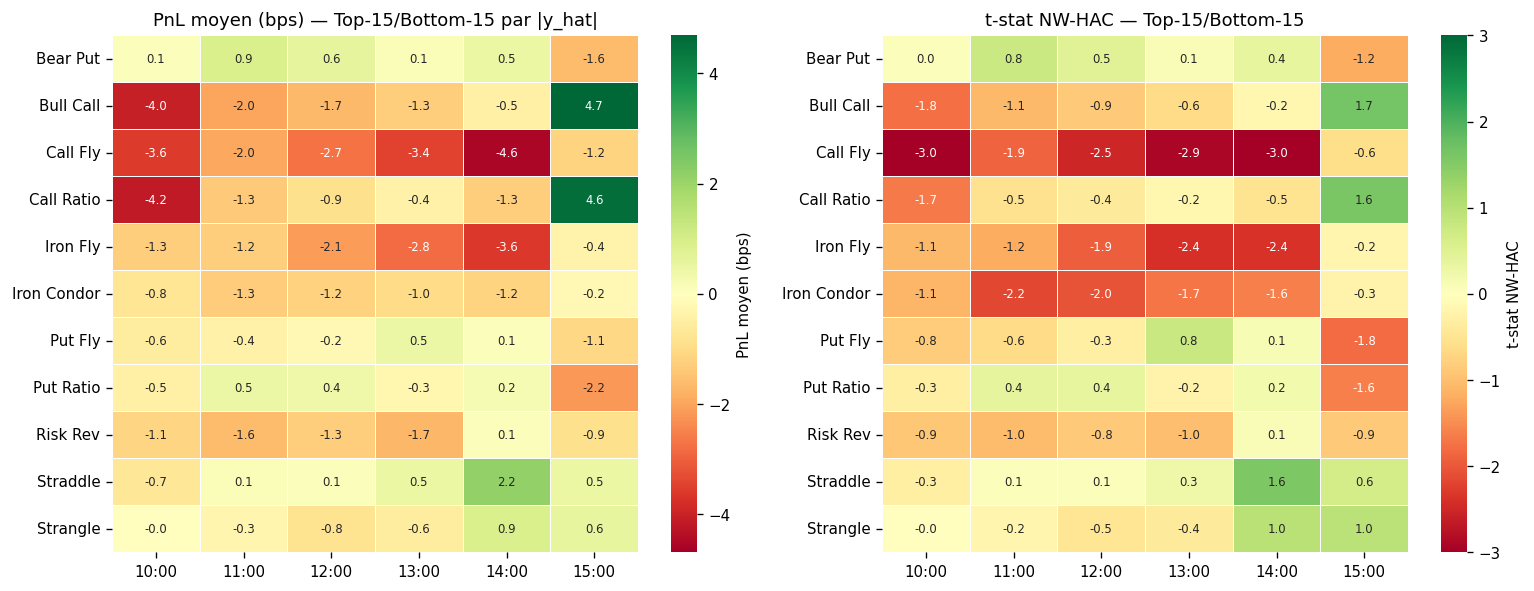

In [ ]:
# ── Heatmap Top-K ──────────────────────────────────────────────────────────────
mat_tk_pnl   = pd.DataFrame(index=mat_pnl.index, columns=SEL_HOURS, dtype=float)
mat_tk_tstat = mat_tk_pnl.copy()

for ot, fam in zip(families_ord, mat_pnl.index):
    for t in SEL_HOURS:
        grp = rep_sub[(rep_sub['option_type'] == ot) & (rep_sub['quote_time'] == t)]
        daily_pnl = grp.groupby('quote_date')['cond_topk'].sum().dropna()
        if len(daily_pnl) < 10:
            continue
        mat_tk_pnl.loc[fam, t]   = daily_pnl.mean()
        mat_tk_tstat.loc[fam, t] = nw_tstat(daily_pnl)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vmax2 = np.nanmax(np.abs(mat_tk_pnl.values.astype(float))) * 1e4
sns.heatmap(
    mat_tk_pnl.astype(float) * 1e4, ax=axes[0],
    center=0, vmin=-vmax2, vmax=vmax2, cmap='RdYlGn',
    annot=True, fmt='.1f', annot_kws={'size': 7}, linewidths=.3,
    cbar_kws={'label': 'PnL moyen (bps)'}
)
axes[0].set_title(f'PnL moyen (bps) — Top-{TOPK}/Bottom-{TOPK} par |y_hat|')

sns.heatmap(
    mat_tk_tstat.astype(float), ax=axes[1],
    center=0, vmin=-3, vmax=3, cmap='RdYlGn',
    annot=True, fmt='.1f', annot_kws={'size': 7}, linewidths=.3,
    cbar_kws={'label': 't-stat NW-HAC'}
)
axes[1].set_title(f't-stat NW-HAC — Top-{TOPK}/Bottom-{TOPK}')

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'reg_topk_heatmap.pdf'), bbox_inches='tight')
plt.show()